In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import confusion_matrix ,ConfusionMatrixDisplay
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.metrics import accuracy_score ,classification_report

In [2]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print(X.shape)
print(y.shape)

(303, 13)
(303, 1)


In [3]:
df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [7]:
df['num'].value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [9]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [10]:
df[df.isnull().any(axis=1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
87,53,0,3,128,216,0,2,115,0,0.0,1,0.0,NaN,0
166,52,1,3,138,223,0,0,169,0,0.0,1,NaN,3.0,0
192,43,1,4,132,247,1,2,143,1,0.1,2,NaN,7.0,1
266,52,1,4,128,204,1,0,156,1,1.0,2,0.0,NaN,2
287,58,1,2,125,220,0,0,144,0,0.4,2,NaN,7.0,0
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0


# EDA

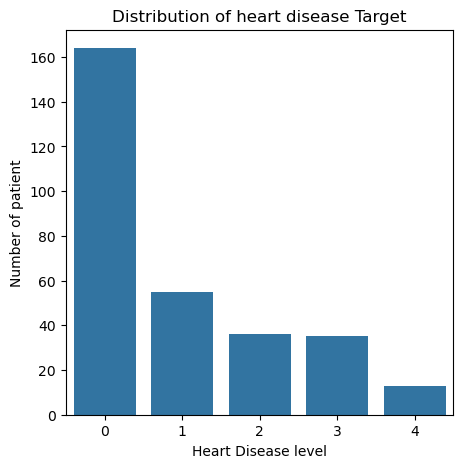

In [11]:
plt.figure(figsize=(5,5))
sns.countplot(data=df,x='num')
plt.title("Distribution of heart disease Target")
plt.xlabel("Heart Disease level")
plt.ylabel("Number of patient")
plt.show()

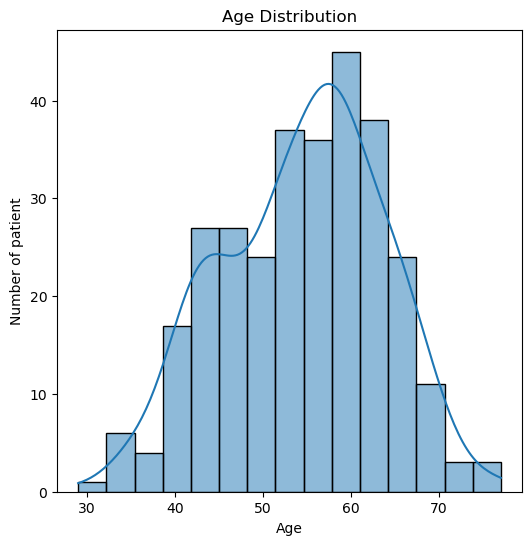

In [12]:
plt.figure(figsize=(6,6))
sns.histplot(data=df,x='age',bins=15,kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of patient")
plt.show()

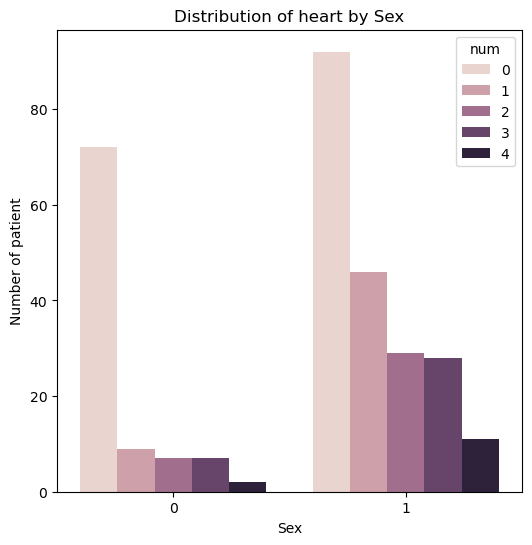

In [13]:
plt.figure(figsize=(6,6))
sns.countplot(data=df,x='sex',hue='num')
plt.title("Distribution of heart by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of patient")
plt.show()

In [14]:
# df.hist(bins=20,figsize=(12,10))
# plt.show()

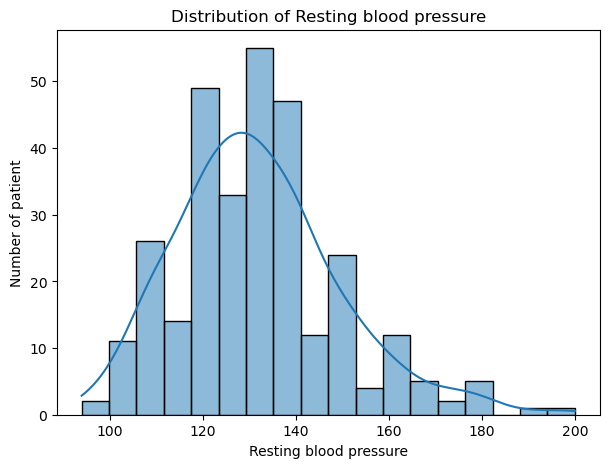

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='trestbps',kde=True)
plt.title("Distribution of Resting blood pressure")
plt.xlabel("Resting blood pressure")
plt.ylabel("Number of patient")
plt.show()

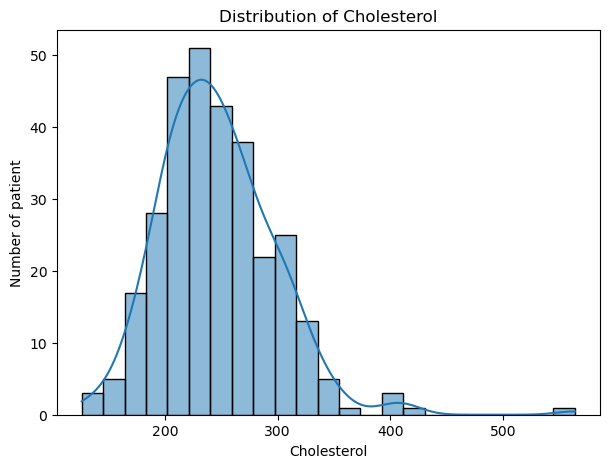

In [16]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='chol',kde=True)
plt.title("Distribution of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Number of patient")
plt.show()

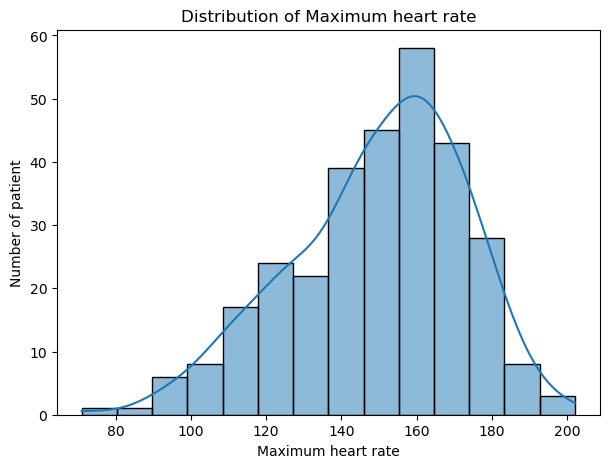

In [17]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='thalach',kde=True)
plt.title("Distribution of Maximum heart rate")
plt.xlabel("Maximum heart rate")
plt.ylabel("Number of patient")
plt.show()

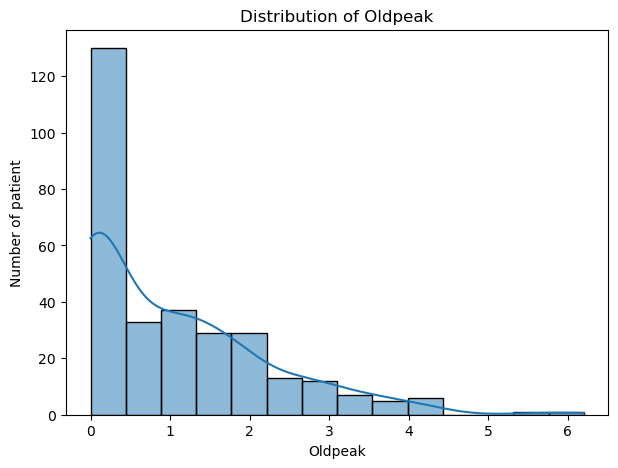

In [18]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,x='oldpeak',kde=True)
plt.title("Distribution of Oldpeak")
plt.xlabel("Oldpeak")
plt.ylabel("Number of patient")
plt.show()

In [19]:
# Feature vs target analysis

In [20]:
df['target']=(df['num']>0).astype(int) # zerop ko hta kr baki saro ko 1 kr diya

In [21]:
df['target'].value_counts() 

target
0    164
1    139
Name: count, dtype: int64

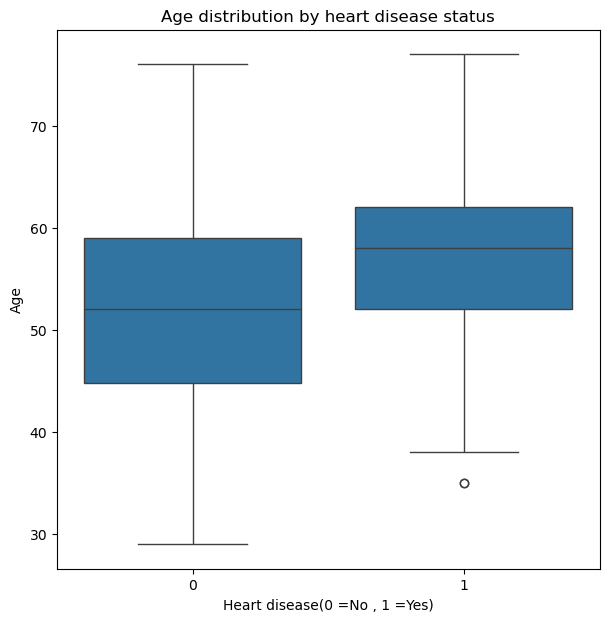

In [22]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df,x='target',y='age')
plt.title("Age distribution by heart disease status")
plt.xlabel("Heart disease(0 =No , 1 =Yes)")
plt.ylabel("Age")
plt.show()

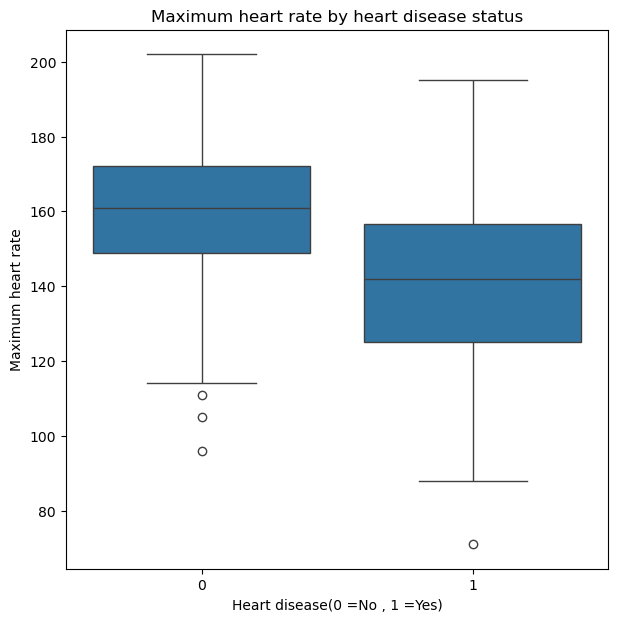

In [23]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df,x='target',y='thalach')
plt.title("Maximum heart rate by heart disease status")
plt.xlabel("Heart disease(0 =No , 1 =Yes)")
plt.ylabel("Maximum heart rate")
plt.show()

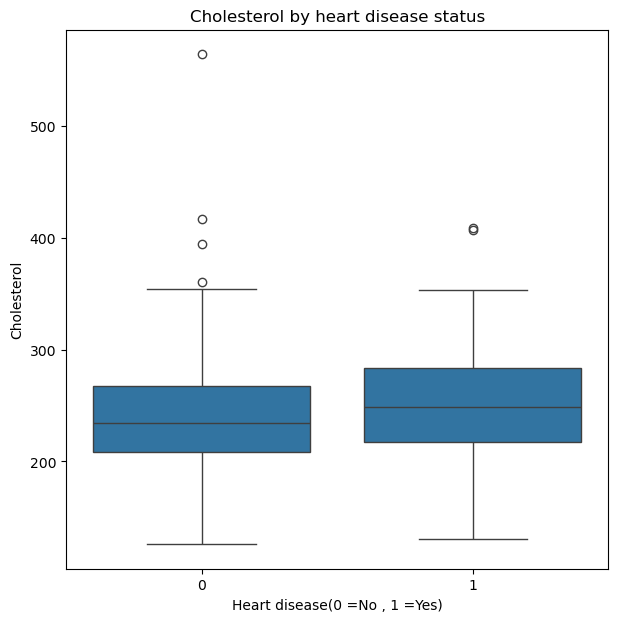

In [24]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df,x='target',y='chol')
plt.title("Cholesterol by heart disease status")
plt.xlabel("Heart disease(0 =No , 1 =Yes)")
plt.ylabel("Cholesterol")
plt.show()

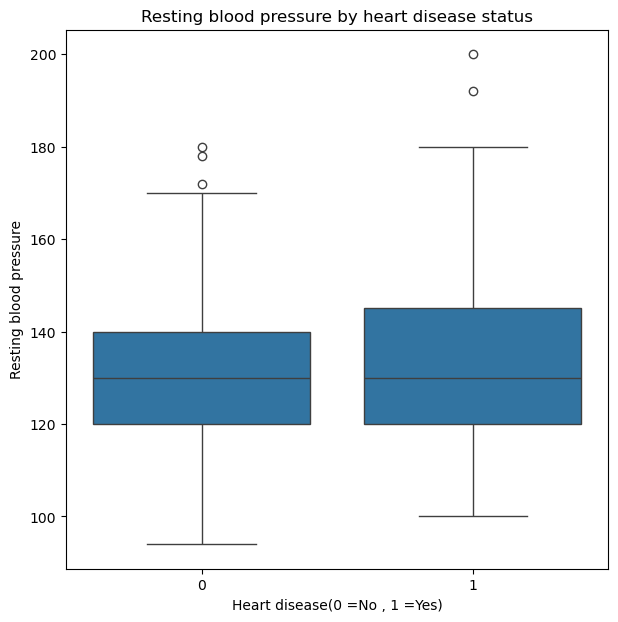

In [25]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df,x='target',y='trestbps')
plt.title("Resting blood pressure by heart disease status")
plt.xlabel("Heart disease(0 =No , 1 =Yes)")
plt.ylabel("Resting blood pressure")
plt.show()

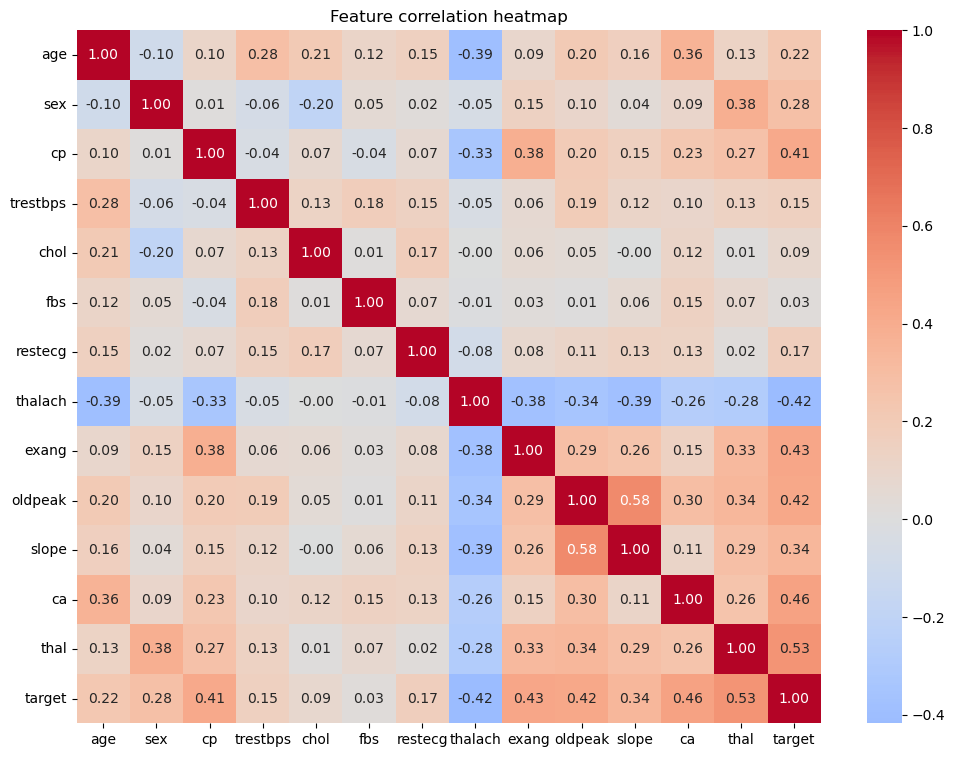

In [26]:
plt.figure(figsize=(12,9))
corr =df.drop(columns=['num']).corr()
sns.heatmap(corr ,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title("Feature correlation heatmap")
plt.show()

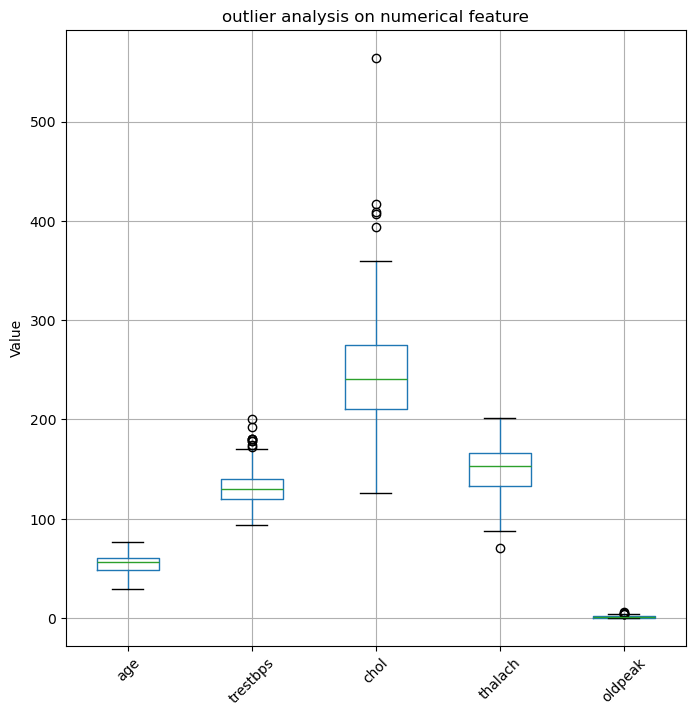

In [27]:
num_feature = ['age','trestbps','chol','thalach','oldpeak']

plt.figure(figsize=(8,8))
df[num_feature].boxplot()
plt.title("outlier analysis on numerical feature")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

In [28]:
# calculating acutual number of outliers

for col in num_feature:
    Q1 =df[col].quantile(0.25)
    Q3 =df[col].quantile(0.75)

    IQR = Q3-Q1
    upper= Q3 +1.5*IQR
    lower= Q1 -1.5*IQR

    find_outlier =df[(df[col] > upper) | (df[col]<lower)]
    print(f"{col} : {len(find_outlier)} outliers")

age : 0 outliers
trestbps : 9 outliers
chol : 5 outliers
thalach : 1 outliers
oldpeak : 5 outliers


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.shape

(303, 15)

In [31]:
print("Duplicated rows : " , df.duplicated().sum())

Duplicated rows :  0


# Pipeline

In [32]:
import pickle
MODEL_FILE = "model.pkl"

In [33]:
def build_pipeline(num_features ,cat_features):
    num_pipeliine = Pipeline([
        ('imputer',SimpleImputer(strategy="median")),
        ('scaler',StandardScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer',SimpleImputer(strategy="median")),
        ('endcoder' ,OneHotEncoder(handle_unknown='ignore'))
    ])

    main_pipeline = ColumnTransformer([
        ('num' ,num_pipeliine ,num_features),
        ('cat',cat_pipeline,cat_features)
    ])

    return main_pipeline

In [36]:
import os
import joblib
if not os.path.exists(MODEL_FILE):
    X= df.drop(columns=['num','target'])
    y=df['target']
    from sklearn.model_selection import train_test_split
    X_train ,X_test,y_train,y_test = train_test_split(X,y ,stratify=y,random_state=42)
    inputs =X_test.copy()
    inputs.to_csv("input.csv" ,index=False)
    
    num_features = ['age','trestbps','chol','thalach','oldpeak']
    cat_features = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

    pipeline = build_pipeline(num_features,cat_features)
    from sklearn.ensemble import RandomForestClassifier
    final_model = Pipeline([
        ('preprocessor',pipeline),
        ('model',RandomForestClassifier(n_estimators=200 ,random_state=42))
    ])
    final_model.fit(X_train,y_train)

    joblib.dump(final_model ,MODEL_FILE)

    print("Model trained and Saved")
else :
    #inference phase
    final_model =joblib.load(MODEL_FILE)

    input_data =pd.read_csv("input.csv")

    prediction =final_model.predict(input_data)
    # Create output
    output = input_data.copy()

    output["Predicted Disease"] = prediction
    
    probabilities =final_model.predict_proba(input_data)[:,1]
    output['Diease_probability'] =probabilities
    output["Predicted Disease"] = output["Predicted Disease"].map({
        0: "No Disease",
        1: "Disease"
    })

    # Save output CSV
    output.to_csv("output.csv", index=False)

    print("Prediction completed successfully")
    print("Output saved as output.csv")
    

Prediction completed successfully
Output saved as output.csv


In [37]:
output= pd.read_csv("output.csv")
print(output.shape)
print(output.head())

(76, 15)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    0   4       106   223    0        0      142      0      0.3      1   
1   41    1   2       135   203    0        0      132      0      0.0      2   
2   66    0   1       150   226    0        0      114      0      2.6      3   
3   57    1   4       130   131    0        0      115      1      1.2      2   
4   69    1   1       160   234    1        2      131      0      0.1      2   

    ca  thal Predicted Disease  Diease_probability  
0  2.0   3.0        No Disease               0.355  
1  0.0   6.0        No Disease               0.400  
2  0.0   3.0        No Disease               0.275  
3  1.0   7.0           Disease               0.935  
4  1.0   3.0           Disease               0.665  


In [38]:
check_accuracy =accuracy_score(y_test,prediction)
print(f"Accuracy is : {check_accuracy}")

Accuracy is : 0.868421052631579


In [39]:
import sklearn
print(sklearn.__version__)

1.7.2
